# Cross-species module validation

## tl;dr

Translation of reference marker modules through the BLAST maps supports
all four pre-specified correspondence tests. The zebrafish LRE module
in Pristina anterior/mid-intestine 2 is the strongest signal
(permutation z = 47.3; FDR = 0.0005).

## Context & Methods

Reference matrices were normalized to 10,000 counts per cell and
log1p-transformed. For each pre-specified reference type, the analysis
selected up-regulated markers, translated each marker to its best
Pristina BLAST hit, and averaged gene-wise z-scored Pristina expression.

The one-sided permutation p-value is
`p = (1 + #{T_perm ≥ T_obs}) / (R + 1)`, with `R = 2,000` random
label sets of the same size as the expected Pristina population.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "public_results").exists():
    ROOT = ROOT.parent
PUBLIC = ROOT / "public_results"

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Data

In [2]:
enrichment = pd.read_csv(PUBLIC / "cross_species_module_enrichment.csv")
modules = pd.read_csv(PUBLIC / "translated_reference_marker_modules.csv")
enrichment

,test_id,reference_species,reference_cell_type,expected_pristina_cell_type,reference_markers_tested,translated_module_genes,expected_pristina_cells,observed_mean_z_module_score,permutation_z_score,one_sided_permutation_p,permutations,bh_fdr
0,human_colonocyte,hs,Colonocyte,stomach 2,50,30,265,0.060873,5.444975,0.0005,2000,0.0005
1,human_paneth,hs,Paneth,anterior/mid-intestine 2,50,24,514,0.119909,12.380742,0.0005,2000,0.0005
2,human_enterocyte,hs,Enterocyte,anterior intestine,50,38,1429,0.026900,6.713934,0.0005,2000,0.0005
3,zebrafish_lre,dr,LRE,anterior/mid-intestine 2,50,38,514,0.401715,47.285920,0.0005,2000,0.0005


## Results

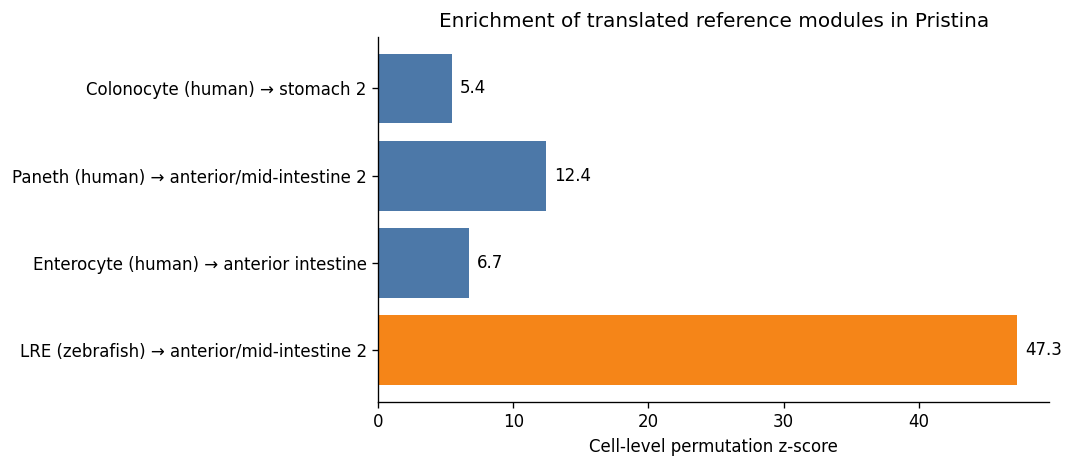

In [3]:
labels = (
    enrichment["reference_cell_type"] + " (" +
    enrichment["reference_species"].map({"hs": "human", "dr": "zebrafish"}) + ") → " +
    enrichment["expected_pristina_cell_type"]
)
colors = enrichment["reference_species"].map({"hs": "#4C78A8", "dr": "#F58518"})
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(labels, enrichment["permutation_z_score"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Cell-level permutation z-score")
ax.set_title("Enrichment of translated reference modules in Pristina")
for i, value in enumerate(enrichment["permutation_z_score"]):
    ax.text(value + 0.6, i, f"{value:.1f}", va="center")
fig.tight_layout()
plt.show()

In [4]:
enrichment[[
    "reference_cell_type", "expected_pristina_cell_type",
    "translated_module_genes", "expected_pristina_cells",
    "permutation_z_score", "one_sided_permutation_p", "bh_fdr",
]]

,reference_cell_type,expected_pristina_cell_type,translated_module_genes,expected_pristina_cells,permutation_z_score,one_sided_permutation_p,bh_fdr
0,Colonocyte,stomach 2,30,265,5.444975,0.0005,0.0005
1,Paneth,anterior/mid-intestine 2,24,514,12.380742,0.0005,0.0005
2,Enterocyte,anterior intestine,38,1429,6.713934,0.0005,0.0005
3,LRE,anterior/mid-intestine 2,38,514,47.285920,0.0005,0.0005


In [5]:
module_counts = modules.groupby(["test_id", "reference_cell_type", "expected_pristina_cell_type"]).size().reset_index(name="translated_genes")
module_counts

,test_id,reference_cell_type,expected_pristina_cell_type,translated_genes
0,human_colonocyte,Colonocyte,stomach 2,30
1,human_enterocyte,Enterocyte,anterior intestine,38
2,human_paneth,Paneth,anterior/mid-intestine 2,26
3,zebrafish_lre,LRE,anterior/mid-intestine 2,39


## Takeaways

- The LRE signal is substantially stronger than the other planned tests.
- The human Paneth, enterocyte, and colonocyte modules provide
  convergent program-level support for their respective candidates.
- These are **cell-level exploratory** tests. They do not replace
  animal/donor-aware pseudobulk testing, and they do not prove that
  Pristina cells have identical mammalian or zebrafish identities.